In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mahad049/college-placement/placement-dataset.csv


In [30]:
df = pd.read_csv('/kaggle/input/datasets/mahad049/college-placement/placement-dataset.csv')

In [31]:
df

,city,cgpa,iq,placement
0,New York,6.8,123.0,1
1,Los Angeles,5.9,106.0,0
2,Chicago,NaN,121.0,0
3,New York,7.4,132.0,1
4,Los Angeles,5.8,142.0,0
...,...,...,...,...
95,Chicago,4.3,200.0,0
96,New York,4.4,42.0,0
97,Los Angeles,6.7,182.0,1
98,Chicago,6.3,103.0,1


In [32]:
df.isnull().sum()

city         0
cgpa         8
iq           4
placement    0
dtype: int64

In [33]:
df.dropna(inplace=True)

In [34]:
df

,city,cgpa,iq,placement
0,New York,6.8,123.0,1
1,Los Angeles,5.9,106.0,0
3,New York,7.4,132.0,1
4,Los Angeles,5.8,142.0,0
5,Chicago,7.1,48.0,1
...,...,...,...,...
95,Chicago,4.3,200.0,0
96,New York,4.4,42.0,0
97,Los Angeles,6.7,182.0,1
98,Chicago,6.3,103.0,1


In [35]:
df.drop(columns=['city'],inplace=True)

In [36]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
3,7.4,132.0,1
4,5.8,142.0,0
5,7.1,48.0,1
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [37]:
X = df.iloc[:,0:2]
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
3,7.4,132.0
4,5.8,142.0
5,7.1,48.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [38]:
y = df.iloc[:,-1]
y

0     1
1     0
3     1
4     0
5     1
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 88, dtype: int64

<Axes: xlabel='cgpa', ylabel='iq'>

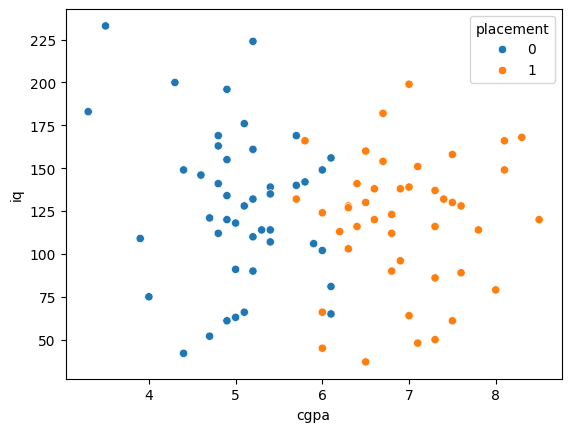

In [49]:
import seaborn as sns
sns.scatterplot(x=df['cgpa'],y=df['iq'],hue=df['placement'])

In [62]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = Perceptron()
clf.fit(X_train,y_train)
y_predict = clf.predict(X_test)
score = accuracy_score(y_test, y_predict)
print(f"Accuracy Score: {score:.2f} | It means {score*100:.2f}% predictions are correct")

Accuracy Score: 0.61 | It means 61.11% predictions are correct


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

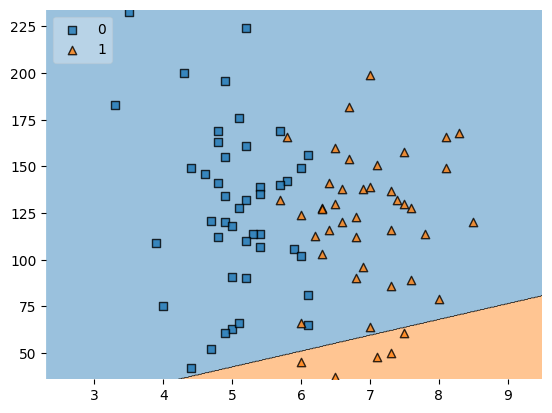

In [63]:
from mlxtend.plotting import plot_decision_regions
# Plotting decision regions
plot_decision_regions(X.values, y.values, clf=clf, legend=2)

In [64]:
clf.coef_

array([[389.8, -46. ]])

In [65]:
clf.intercept_

array([12.])